# Tutorial 5: Split Oversized Traces

## The Problem

Some traces in the dataset are abnormally large.
This happens when the tracing algorithm incorrectly groups **multiple chromatin fibers** into a single trace.
These oversized traces distort downstream distance and contact analyses.

## How `trace_splitter` Works

`trace_splitter` uses a two-step approach:

1. **Measure trace size** — Compute the **radius of gyration (Rg)** of each trace.
   Rg is the average distance of all barcode positions from the trace’s center of mass:

   `Rg = sqrt( mean( |position - center_of_mass|² ) )`

   A larger Rg means the trace is more spread out in 3D space.

2. **Split large traces** — Traces with Rg above a threshold (`mean + std_threshold × std`)
   are split into sub-traces using **K-means clustering** on their 3D coordinates.
   Each resulting cluster gets a new Trace_ID.

## Input

The duplicate-cleaned trace file from Tutorial 4: `merged_traces_cleaned_intensity.ecsv`

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data"
dest_path = f"{data_path}/output"

input_trace = f"{dest_path}/merged_traces_cleaned_intensity.ecsv"

print(f"Input: {input_trace}")

Input: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv


## Step 1: Run QC Before Splitting

First, let’s run `trace_analyzer` on the input to have a reference for comparison.

In [2]:
!trace_analyzer --input {input_trace}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
$ Number of spots in trace file: 107403


$ Calculating overall barcode detection across 20682 traces...


$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_barcode_detection.png


$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.002


...

 95%|█████████████████████████████████  | 19572/20682 [00:02<00:00, 7429.41it/s]

 98%|██████████████████████████████████▍| 20316/20682 [00:02<00:00, 7381.59it/s]

100%|███████████████████████████████████| 20682/20682 [00:02<00:00, 7114.80it/s]


$ Exporting relative barcode frequencies figure to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_relative_barcode_frequencies.png


Finished execution


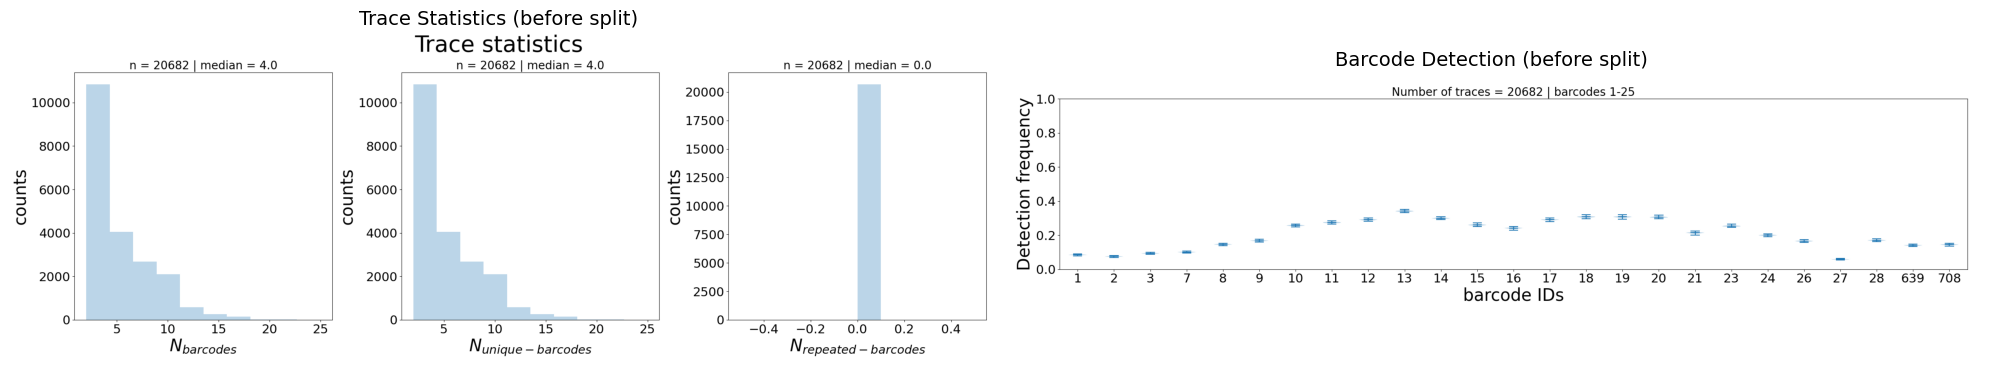

In [3]:
# Display reference plots
before_stats = f"{dest_path}/merged_traces_cleaned_intensity_trace_statistics.png"
before_detect = f"{dest_path}/merged_traces_cleaned_intensity_barcode_detection.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_stats, before_detect],
                         ["Trace Statistics (before split)", "Barcode Detection (before split)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Split Oversized Traces

Run `trace_splitter` with default parameters:
- `--std_threshold 1.0` — split traces with Rg > mean + 1×std
- `--num_clusters 2` — split each oversized trace into 2 sub-traces

In [4]:
!trace_splitter --input {input_trace}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
Applying K-means clustering with 2 clusters on traces with Rg > mean + 1.0 * std_dev...


$ Mean Rg: 0.204, Std Rg: 0.139, Threshold: 0.344


$ Splitting trace 00517e61-6ca8-421b-a88d-662212fd8115 (Rg=0.363) into 2 clusters.


$ Splitting trace 0062f5ec-934d-41c0-b027-85b7cd55959b (Rg=0.377) into 2 clusters.
$ Splitting trace 00a9d3f2-1e74-4b93-810f-7595d688b01a (Rg=0.642) into 2 clusters.
$ Splitting trace 00befdeb-adc4-49a9-9f04-a133ae4e92b6 (Rg=0.525) into 2 clusters.


...

$ Splitting trace fdbaeac3-43fa-419a-b237-01431b91f3cf (Rg=0.688) into 2 clusters.
$ Splitting trace fdee5042-d122-475e-8ddf-d149b5ec9091 (Rg=0.679) into 2 clusters.
$ Splitting trace fdff01bb-8a45-402e-a27d-4c539b85a96e (Rg=0.378) into 2 clusters.
$ Splitting trace fe1dac19-892e-45c0-bf41-e91dcdcec925 (Rg=0.568) into 2 clusters.


$ Splitting trace fe4297aa-e98f-426c-a1ab-992a0b929eb9 (Rg=0.663) into 2 clusters.
$ Splitting trace fe500162-1667-4bc2-9151-bdd4eed2ac32 (Rg=0.365) into 2 clusters.
$ Splitting trace fe5625c6-15e8-4392-b002-c256d05ad0e4 (Rg=0.345) into 2 clusters.
$ Splitting trace fe5a2a9d-d111-4a52-87be-25e4f465fcbc (Rg=0.499) into 2 clusters.
$ Splitting trace fe766c1e-d87d-4720-a525-394aefa6f6da (Rg=0.406) into 2 clusters.


$ Splitting trace fed55aa4-e438-46aa-8c89-bab7207406d1 (Rg=0.356) into 2 clusters.
$ Splitting trace ff44b3e0-567c-4afb-92e6-24e389ac99ee (Rg=0.364) into 2 clusters.
$ Splitting trace ff8e2b81-ce0b-4338-90e9-9acfcb955db6 (Rg=0.532) into 2 clusters.


$ Splitting trace ff96c1b9-b750-413a-aef7-f96b35e35685 (Rg=0.364) into 2 clusters.
$ Splitting trace ffd9ac8d-a843-416c-b8ef-3b267c63b087 (Rg=0.348) into 2 clusters.
$ Splitting trace ffe0b2ef-af7f-4b39-b1bf-04fac8a57526 (Rg=0.437) into 2 clusters.
$ Splitting trace ffe8207a-0b70-4f07-ba80-f1d361e6ab6c (Rg=0.733) into 2 clusters.


$ Splitting trace fff7b032-66bd-4d4e-a602-81b365250d7b (Rg=0.539) into 2 clusters.
$ Number of traces split: 2206/20682
$ Saving output table as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split.ecsv ...


The output reports:
- The computed **Mean Rg**, **Std Rg**, and **Threshold**
- Each trace that was split, with its Rg value
- Total number of traces split vs total

The output file is saved as `<input>_split.ecsv` alongside the input.

## Step 3: Compare Before vs After

Run `trace_analyzer` on the split output and compare the trace statistics.

In [5]:
split_trace = f"{dest_path}/merged_traces_cleaned_intensity_split.ecsv"
!trace_analyzer --input {split_trace}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split.ecsv
$ Number of spots in trace file: 107403


$ Calculating overall barcode detection across 22888 traces...


$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split_barcode_detection.png


$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.002


...

 95%|█████████████████████████████████▍ | 21831/22888 [00:03<00:00, 6815.31it/s]

 98%|██████████████████████████████████▍| 22513/22888 [00:03<00:00, 6481.39it/s]

100%|███████████████████████████████████| 22888/22888 [00:03<00:00, 6609.32it/s]


$ Exporting relative barcode frequencies figure to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_split_relative_barcode_frequencies.png


Finished execution


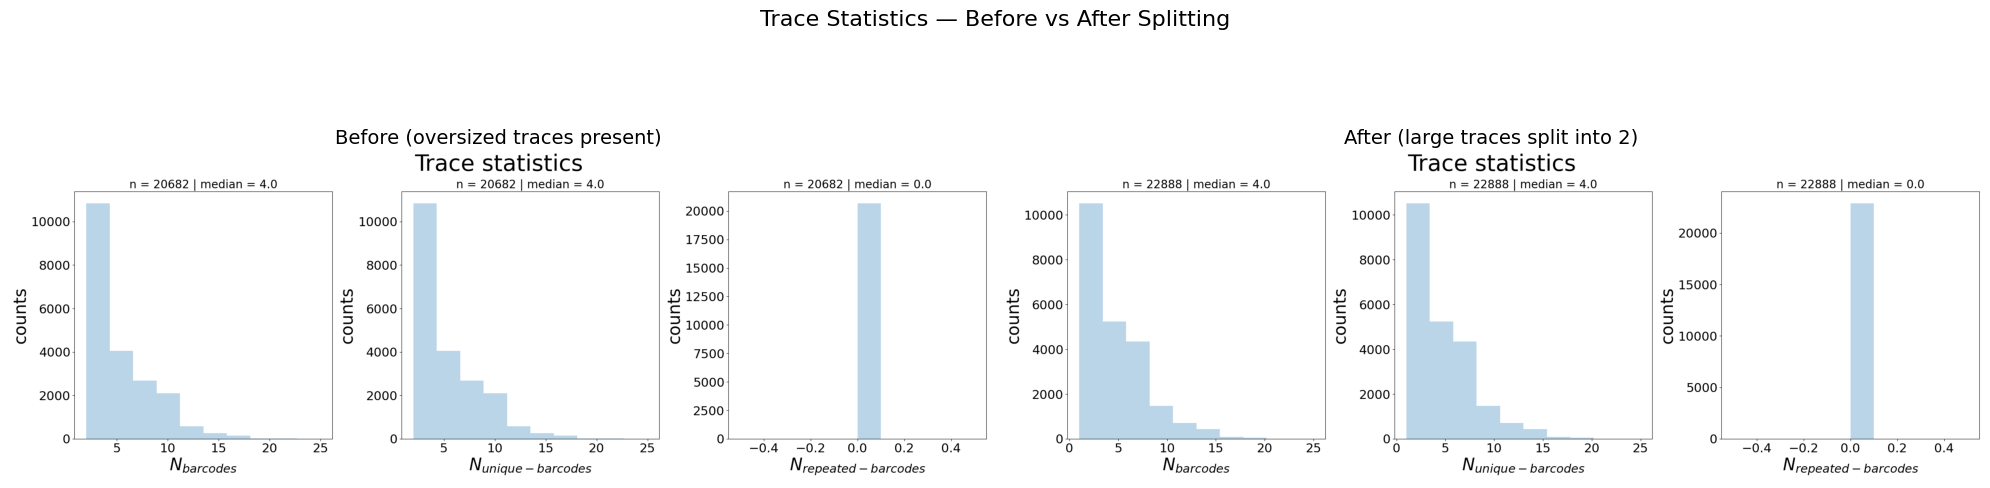

In [6]:
# Compare: Trace Statistics before vs after
after_stats = f"{dest_path}/merged_traces_cleaned_intensity_split_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_stats, after_stats],
                         ["Before (oversized traces present)",
                          "After (large traces split into 2)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Before vs After Splitting", fontsize=16)
plt.tight_layout()
plt.show()

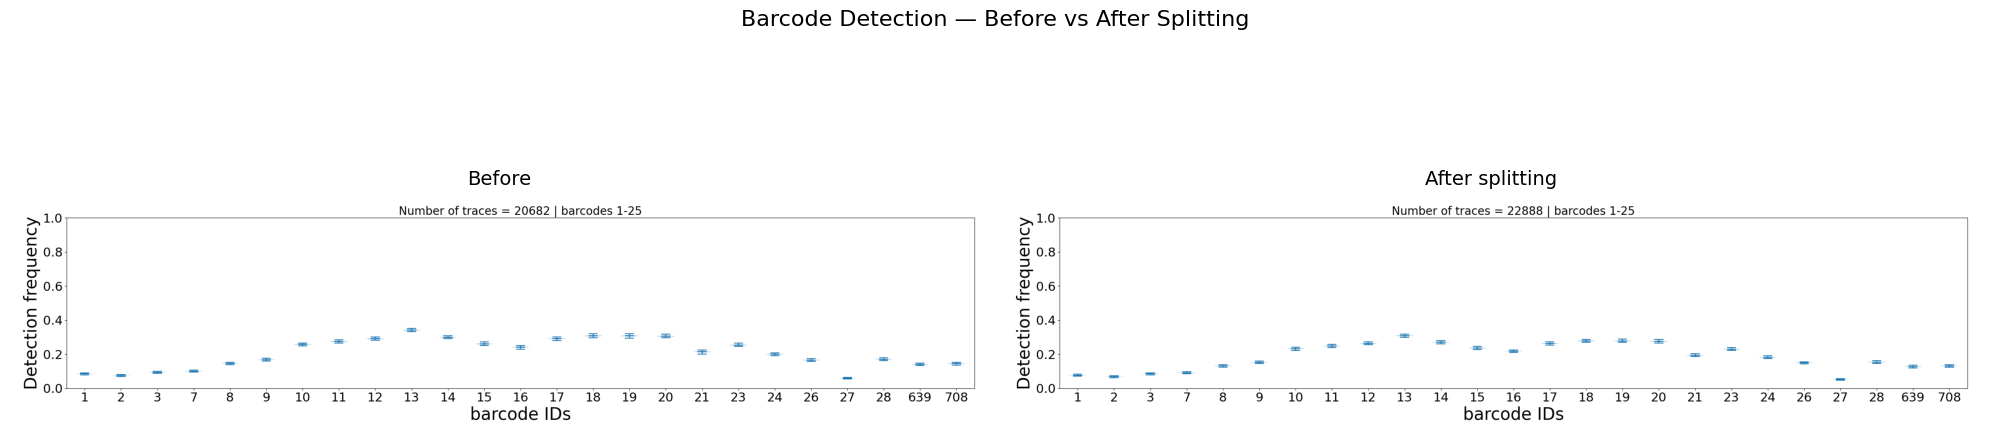

In [7]:
# Compare: Barcode Detection before vs after
after_detect = f"{dest_path}/merged_traces_cleaned_intensity_split_barcode_detection.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_detect, after_detect],
                         ["Before", "After splitting"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Barcode Detection — Before vs After Splitting", fontsize=16)
plt.tight_layout()
plt.show()

**What to check:**
- **N_barcodes** (left panel) shifts left: split traces have fewer barcodes each
- **Total trace count** increases: each split creates one extra trace
- **Barcode detection** may change slightly as trace composition is modified

## About the Parameters

`trace_splitter` accepts two parameters with sensible defaults:

| Parameter | Default | Effect |
|-----------|---------|--------|
| `--std_threshold` | 1.0 | Traces with Rg > mean + N×std are split. Lower = more aggressive. |
| `--num_clusters` | 2 | Number of sub-traces after splitting. |

**The defaults are recommended for most datasets.** Changing them requires a good reason:

- Lowering `--std_threshold` (e.g. 0.5) splits more traces, risking splitting
  legitimate extended conformations
- Raising `--std_threshold` (e.g. 2.0) only splits extreme outliers
- `--num_clusters 3` would only make sense if you suspect
  three distinct fibers were merged into a single trace, which is rare

When in doubt, keep the defaults and inspect the results.

## Summary

| What | How |
|------|-----|
| Detect oversized traces | Radius of gyration (Rg) > mean + std |
| Split them | K-means clustering on 3D coordinates |
| Default behavior | Split into 2, threshold at mean + 1×std |

`trace_splitter` only modifies traces above the Rg threshold.
All other traces pass through unchanged.

**Next:** [Tutorial 6 — Assign Masks & Split by Labels](tutorial_06_assign_masks_split_labels.ipynb)